In [26]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report,confusion_matrix,roc_auc_score,precision_recall_curve,roc_curve)

In [2]:
df = pd.read_csv('safaricom_churn.csv')
df.head()

,CustomerID,Region,Age,Plan,DeviceType,CustomerSegment,TenureMonths,MonthlyDataGB,MonthlyVoiceMins,MonthlySMSCount,...,HasShowmax,HasInternationalRoaming,NumServices,CustomerServiceCalls,NetworkComplaints,UnresolvedComplaints,NetworkQualityScore,DaysSinceLastTopup,ContractMonths,Churned
0,SAF000001,Mombasa,50,Prepaid,Smartphone,Consumer,86,1.36,102.0,14.0,...,1,0,2,1,0,0,8.3,7.0,0,0
1,SAF000002,Meru,49,Prepaid,Smartphone,SME,2,0.23,143.0,96.0,...,0,0,2,3,0,0,8.0,22.0,0,0
2,SAF000003,Eldoret,26,Postpaid,Smartphone,SME,4,0.64,64.0,4.0,...,1,0,2,3,0,0,9.2,1.0,12,0
3,SAF000004,Kisumu,28,Prepaid,Smartphone,Consumer,45,1.85,240.0,88.0,...,1,1,3,0,1,1,9.9,1.0,0,0
4,SAF000005,Nairobi,54,Postpaid,Smartphone,Consumer,13,2.53,45.0,0.0,...,0,0,1,1,0,0,8.8,1.0,12,0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 24 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   CustomerID                5000 non-null   object 
 1   Region                    5000 non-null   object 
 2   Age                       5000 non-null   int64  
 3   Plan                      5000 non-null   object 
 4   DeviceType                5000 non-null   object 
 5   CustomerSegment           5000 non-null   object 
 6   TenureMonths              5000 non-null   int64  
 7   MonthlyDataGB             4975 non-null   float64
 8   MonthlyVoiceMins          5000 non-null   float64
 9   MonthlySMSCount           5000 non-null   float64
 10  MonthlyMpesaTransactions  5000 non-null   float64
 11  MonthlySpendKES           5000 non-null   float64
 12  HasMpesa                  5000 non-null   int64  
 13  HasSafaricomHome          5000 non-null   int64  
 14  HasShowm

In [4]:
df.fillna(df.select_dtypes(include='number').mean(), inplace=True)
df.info()
df.describe()
df.columns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 24 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   CustomerID                5000 non-null   object 
 1   Region                    5000 non-null   object 
 2   Age                       5000 non-null   int64  
 3   Plan                      5000 non-null   object 
 4   DeviceType                5000 non-null   object 
 5   CustomerSegment           5000 non-null   object 
 6   TenureMonths              5000 non-null   int64  
 7   MonthlyDataGB             5000 non-null   float64
 8   MonthlyVoiceMins          5000 non-null   float64
 9   MonthlySMSCount           5000 non-null   float64
 10  MonthlyMpesaTransactions  5000 non-null   float64
 11  MonthlySpendKES           5000 non-null   float64
 12  HasMpesa                  5000 non-null   int64  
 13  HasSafaricomHome          5000 non-null   int64  
 14  HasShowm

Index(['CustomerID', 'Region', 'Age', 'Plan', 'DeviceType', 'CustomerSegment',
       'TenureMonths', 'MonthlyDataGB', 'MonthlyVoiceMins', 'MonthlySMSCount',
       'MonthlyMpesaTransactions', 'MonthlySpendKES', 'HasMpesa',
       'HasSafaricomHome', 'HasShowmax', 'HasInternationalRoaming',
       'NumServices', 'CustomerServiceCalls', 'NetworkComplaints',
       'UnresolvedComplaints', 'NetworkQualityScore', 'DaysSinceLastTopup',
       'ContractMonths', 'Churned'],
      dtype='object')

In [5]:
df.duplicated().sum()

np.int64(0)

Text(0.5, 1.0, 'Churned vs Not Churned')

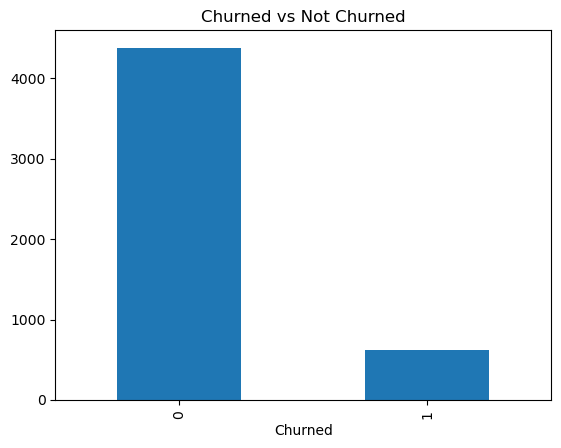

In [6]:
df['Churned'].value_counts().plot(kind='bar')
plt.title('Churned vs Not Churned')

In [7]:
df['Churned'].value_counts()

Churned
0    4381
1     619
Name: count, dtype: int64

In [8]:
df.groupby(['Churned',])['MonthlySpendKES'].mean()

Churned
0    1073.873088
1     999.573506
Name: MonthlySpendKES, dtype: float64

In [9]:
# 1. Which plan has the highest churn rate?
df.groupby('Plan')['Churned'].mean().sort_values(ascending=False)

Plan
Prepaid     0.147636
Hybrid      0.122407
Postpaid    0.071682
Name: Churned, dtype: float64

In [10]:
# 2. Does number of services affect churn?
df.groupby('NumServices')['Churned'].mean()

NumServices
0    0.315789
1    0.145957
2    0.095722
3    0.050239
4    0.040000
Name: Churned, dtype: float64

In [11]:
# 3. Do unresolved complaints drive churn?
df.groupby('UnresolvedComplaints')['Churned'].mean()

UnresolvedComplaints
0    0.101914
1    0.251200
2    0.527778
3    0.500000
Name: Churned, dtype: float64

In [12]:
# 4. Churn by region
df.groupby('Region')['Churned'].mean().sort_values(ascending=False)

Region
Garissa     0.188406
Eldoret     0.132979
Thika       0.129121
Meru        0.125749
Nairobi     0.125353
Nakuru      0.124294
Mombasa     0.122085
Kisumu      0.120240
Nyeri       0.114943
Machakos    0.071713
Name: Churned, dtype: float64

<Figure size 1000x600 with 0 Axes>

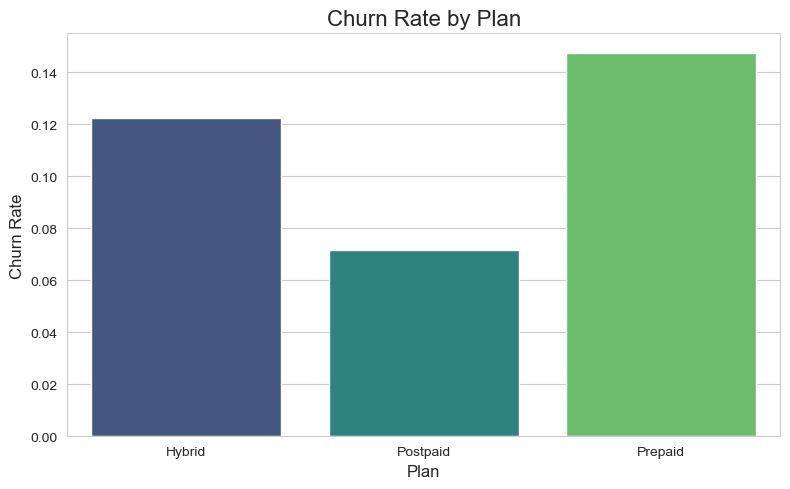

In [13]:
sns.set_style('whitegrid')
plt.figure(figsize=(10,6))

#1 Plan vs Churn
import matplotlib.pyplot as plt
import seaborn as sns

# Group data
plan_churn = df.groupby('Plan')['Churned'].mean().reset_index()

# Create figure
fig, axes = plt.subplots(figsize=(8,5))

# Create barplot
sns.barplot(x='Plan',y='Churned',data=plan_churn,hue='Plan',palette='viridis',legend=False,ax=axes)

# Titles and labels
axes.set_title('Churn Rate by Plan', fontsize=16)
axes.set_xlabel('Plan', fontsize=12)
axes.set_ylabel('Churn Rate', fontsize=12)

plt.tight_layout()
plt.show()

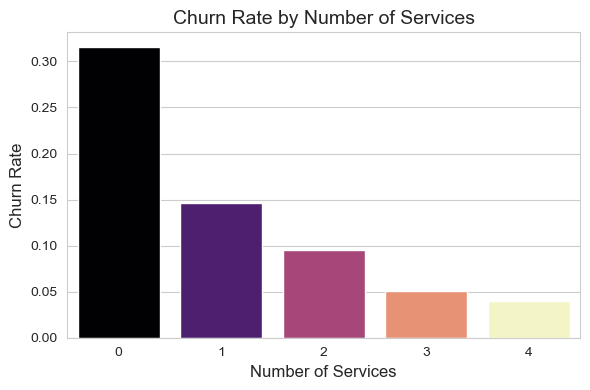

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate churn rate by number of services
services_churn = (df.groupby('NumServices')['Churned'].mean().reset_index().sort_values(by='Churned', ascending=False))

# Create figure
fig, ax = plt.subplots(figsize=(6, 4))

# Create barplot
sns.barplot(data=services_churn,x='NumServices',y='Churned',hue='NumServices',     palette='magma',legend=False,order=services_churn['NumServices'],ax=ax)

ax.set_title('Churn Rate by Number of Services', fontsize=14)
ax.set_ylabel('Churn Rate', fontsize=12)
ax.set_xlabel('Number of Services', fontsize=12)

plt.tight_layout()

plt.show()

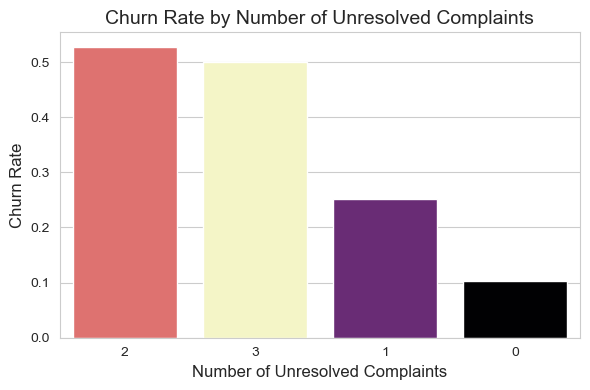

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate churn rate by number of services
services_churn = (df.groupby('UnresolvedComplaints')['Churned'].mean().reset_index().sort_values(by='Churned', ascending=False))

# Create figure
fig, ax = plt.subplots(figsize=(6, 4))

# Create barplot
sns.barplot(data=services_churn,x='UnresolvedComplaints',y='Churned',hue='UnresolvedComplaints',palette='magma',legend=False,order=services_churn['UnresolvedComplaints'],ax=ax)

ax.set_title('Churn Rate by Number of Unresolved Complaints', fontsize=14)
ax.set_ylabel('Churn Rate', fontsize=12)
ax.set_xlabel('Number of Unresolved Complaints', fontsize=12)

plt.tight_layout()

plt.show()

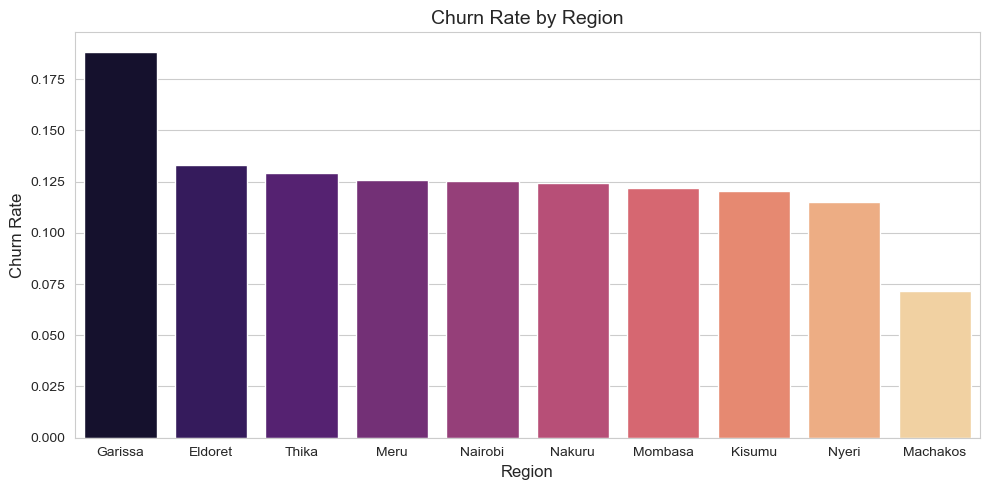

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate churn rate by number of services
services_churn = (df.groupby('Region')['Churned'].mean().reset_index().sort_values(by='Churned', ascending=False))

# Create figure
fig, ax = plt.subplots(figsize=(10, 5))

# Create barplot
sns.barplot(data=services_churn,x='Region',y='Churned',hue='Region',palette='magma',legend=False,order=services_churn['Region'],ax=ax)

ax.set_title('Churn Rate by Region', fontsize=14)
ax.set_ylabel('Churn Rate', fontsize=12)
ax.set_xlabel('Region', fontsize=12)

plt.tight_layout()

plt.show()

In [ ]:
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.compose import make_column_selector as selector

# 1. Define features and target (Dropping known ID columns explicitly)
drop_list = ['Churned', 'CustomerID', 'AccountNo', 'PhoneNumber', 'SubscriberID']
X = df.drop(columns=[col for col in drop_list if col in df.columns], errors='ignore')
y = df['Churned']

print("Columns being trained on:", X.columns.tolist())

print("\nClass Distribution:")
print(y.value_counts())
print("\nClass Percentage:")
print(y.value_counts(normalize=True) * 100)

# 2. Split data with stratification to maintain class balance
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 3. Build preprocessing pipelines
numeric_features = X.select_dtypes(
    include=['int64', 'float64']
).columns

categorical_features = X.select_dtypes(
    include=['object', 'category', 'bool']
).columns

numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median'))
])

categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer([
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features)
])

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median'))
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, selector(dtype_include=['number'])),
    ('cat', categorical_transformer, selector(dtype_include=['object', 'category', 'bool']))
])

# 4. Define the model pipeline with tuned hyperparameters
pipeline = ImbPipeline(steps=[
    ('preprocessor', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('classifier', RandomForestClassifier(
        random_state=42, 
        class_weight='balanced', 
        n_estimators=500,      
        max_depth=20,          
        min_samples_leaf=2,
        min_samples_split=5,
        max_features='sqrt',
        class_weight='balanced_subsample',
        n_jobs=-1    
    ))
])

# 5. Train the pipeline
pipeline.fit(X_train, y_train)

# 6. Predict probabilities instead of hard 0s and 1s
y_prob = pipeline.predict_proba(X_test)[:, 1]

custom_threshold = 0.35
y_pred_custom = (y_prob >= custom_threshold).astype(int)

precision, recall, thresholds = precision_recall_curve(
    y_test,
    y_prob
)

f1_scores = (
    2 * precision * recall
) / (
    precision + recall + 1e-10
)

best_index = np.argmax(f1_scores[:-1])
best_threshold = thresholds[best_index]

print(f"\nBest Threshold: {best_threshold:.4f}")
print(f"Best F1 Score: {f1_scores[best_index]:.4f}")

y_pred = (
    y_prob >= best_threshold
).astype(int)

# 8. Evaluate the performance
print(f"--- Classification Report (Threshold: {custom_threshold}) ---")
print(classification_report(y_test, y_pred_custom))

print("CONFUSION MATRIX")
cm = confusion_matrix(y_test, y_pred)
print(cm)

#ROC AUC Score
roc_auc = roc_auc_score(y_test, y_prob)
print(f"ROC AUC Score: {roc_auc:.4f}")

#FEATURE IMPORTANCE
feature_names = (pipeline.named_steps['preprocessor'].get_feature_names_out())
importances = pipeline.named_steps['classifier'].feature_importances_
feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

Columns being trained on: ['Region', 'Age', 'Plan', 'DeviceType', 'CustomerSegment', 'TenureMonths', 'MonthlyDataGB', 'MonthlyVoiceMins', 'MonthlySMSCount', 'MonthlyMpesaTransactions', 'MonthlySpendKES', 'HasMpesa', 'HasSafaricomHome', 'HasShowmax', 'HasInternationalRoaming', 'NumServices', 'CustomerServiceCalls', 'NetworkComplaints', 'UnresolvedComplaints', 'NetworkQualityScore', 'DaysSinceLastTopup', 'ContractMonths']
--- Classification Report (Threshold: 0.35) ---
              precision    recall  f1-score   support

           0       0.95      0.72      0.82       876
           1       0.27      0.73      0.39       124

    accuracy                           0.72      1000
   macro avg       0.61      0.72      0.60      1000
weighted avg       0.86      0.72      0.76      1000



In [18]:
print(df.columns.tolist())

['CustomerID', 'Region', 'Age', 'Plan', 'DeviceType', 'CustomerSegment', 'TenureMonths', 'MonthlyDataGB', 'MonthlyVoiceMins', 'MonthlySMSCount', 'MonthlyMpesaTransactions', 'MonthlySpendKES', 'HasMpesa', 'HasSafaricomHome', 'HasShowmax', 'HasInternationalRoaming', 'NumServices', 'CustomerServiceCalls', 'NetworkComplaints', 'UnresolvedComplaints', 'NetworkQualityScore', 'DaysSinceLastTopup', 'ContractMonths', 'Churned']
